# **Day 82: Model Deployment - Saving Models, Prediction APIs and ONNX**
*Module 12 - Trustworthy ML and MLOps*

A model in a notebook helps nobody else. **Deployment** makes predictions available: as a file others can load, as a batch job that maps a whole district every month, as a web API a dashboard calls, or embedded in a field app. Today: the main deployment patterns and the engineering habits that make them reliable.

> Deployment makes a trained model usable by others: save it to a file, wrap it in an API that accepts requests, and optionally export it to ONNX so it runs quickly anywhere.
>
> *Example:* A web service receives a field's coordinates and returns the predicted crop type in milliseconds.

In [1]:
import numpy as np
import pandas as pd
import json, time, hashlib, joblib, os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(82)
out = Path("deployment_demo"); out.mkdir(exist_ok=True)

## **1. A Model Worth Deploying**
A land-cover classifier from 6 Sentinel-2 bands + NDVI (pixel-based).

In [2]:
BANDS = ["B2", "B3", "B4", "B8", "B11", "B12"]; CLASSES = ["water", "vegetation", "cropland", "built-up", "bare"]
means = np.array([[0.06, 0.05, 0.03, 0.02, 0.01, 0.01], [0.03, 0.05, 0.03, 0.35, 0.16, 0.08], [0.05, 0.08, 0.06, 0.30, 0.22, 0.13],
                  [0.12, 0.12, 0.13, 0.20, 0.22, 0.20], [0.14, 0.16, 0.20, 0.25, 0.30, 0.26]])
y = rng.integers(0, 5, 5000); X = means[y] * rng.uniform(0.8, 1.2, (5000, 1)) + rng.normal(0, 0.015, (5000, 6))
def add_ndvi(X): X = np.asarray(X, dtype=np.float32); return np.c_[X, (X[:, 3] - X[:, 2]) / (X[:, 3] + X[:, 2] + 1e-6)]
X_tr, X_te, y_tr, y_te = train_test_split(add_ndvi(X), y, test_size=0.2, random_state=0)
model = make_pipeline(StandardScaler(), RandomForestClassifier(200, max_depth=12, random_state=0, n_jobs=-1)).fit(X_tr, y_tr)
print("test accuracy:", round(model.score(X_te, y_te), 4))

test accuracy: 0.968


## **2. Serialisation Options**

| Format | Loads in | Pros | Cons |
|---|---|---|---|
| `joblib` / `pickle` | Python with the **same** library versions | trivial, keeps whole pipeline | **executes code on load: never load untrusted files**; version-fragile |
| `skops.io` | Python | safer pickle alternative for sklearn | Python only |
| `torch.save(state_dict)` | PyTorch | standard for NNs | need the class definition |
| **ONNX** | any language/runtime (C++, C#, Java, JS, mobile), ONNX Runtime | portable, no code execution, fast inference | conversion step; not every op supported |

In [3]:
joblib.dump(model, out / "landcover_rf.joblib", compress=3)
metadata = {"model_name": "landcover_rf", "version": "1.0.0", "trained": time.strftime("%Y-%m-%d"), "inputs": BANDS + ["NDVI"],
            "input_units": "surface reflectance (0-1)", "classes": CLASSES, "test_accuracy": round(model.score(X_te, y_te), 4),
            "sklearn_version": __import__("sklearn").__version__, "sha256": hashlib.sha256(open(out / "landcover_rf.joblib", "rb").read()).hexdigest()[:16]}
(out / "landcover_rf.json").write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=1))
print(f"joblib file size: {os.path.getsize(out / 'landcover_rf.joblib') / 1e6:.2f} MB")

{
 "model_name": "landcover_rf",
 "version": "1.0.0",
 "trained": "2026-10-02",
 "inputs": [
  "B2",
  "B3",
  "B4",
  "B8",
  "B11",
  "B12",
  "NDVI"
 ],
 "input_units": "surface reflectance (0-1)",
 "classes": [
  "water",
  "vegetation",
  "cropland",
  "built-up",
  "bare"
 ],
 "test_accuracy": 0.968,
 "sklearn_version": "1.9.1",
 "sha256": "6994851ff1680c3d"
}
joblib file size: 0.95 MB


### Export to ONNX and run with ONNX Runtime

In [4]:
from skl2onnx import to_onnx
import onnxruntime as ort
onx = to_onnx(model, X_tr[:1].astype(np.float32), target_opset=17, options={id(model.steps[-1][1]): {"zipmap": False}})
(out / "landcover_rf.onnx").write_bytes(onx.SerializeToString())
sess = ort.InferenceSession(str(out / "landcover_rf.onnx"), providers=["CPUExecutionProvider"])
inp = sess.get_inputs()[0].name; outs = [o.name for o in sess.get_outputs()]
onnx_labels, onnx_probs = sess.run(outs, {inp: X_te.astype(np.float32)})
print(f"ONNX output names: {outs} | predictions identical to sklearn: {np.mean(onnx_labels == model.predict(X_te)):.4f}")
print(f"max probability difference: {np.abs(onnx_probs - model.predict_proba(X_te)).max():.2e} | ONNX file {os.path.getsize(out / 'landcover_rf.onnx') / 1e6:.2f} MB")

ONNX output names: ['label', 'probabilities'] | predictions identical to sklearn: 1.0000
max probability difference: 4.67e-07 | ONNX file 2.86 MB


In [5]:
for name, fn in [("sklearn predict_proba", lambda: model.predict_proba(X_te)), ("ONNX Runtime", lambda: sess.run(outs, {inp: X_te.astype(np.float32)}))]:
    fn(); t0 = time.perf_counter(); [fn() for _ in range(5)]; print(f"{name:<22} {(time.perf_counter() - t0) / 5 * 1000:7.1f} ms for {len(X_te)} pixels")

sklearn predict_proba     50.3 ms for 1000 pixels
ONNX Runtime               2.0 ms for 1000 pixels


## **3. Batch Prediction for Large Rasters**
Mapping a district means predicting **millions** of pixels. Never load everything at once: process **blocks** (windows), keep memory bounded, write results incrementally, and handle nodata. (With real GeoTIFFs, use `rasterio` windows, Days 86-91.)

predicted 5.0 M pixels in 27.8s (block-wise, ONNX Runtime) | accuracy vs truth 0.9962


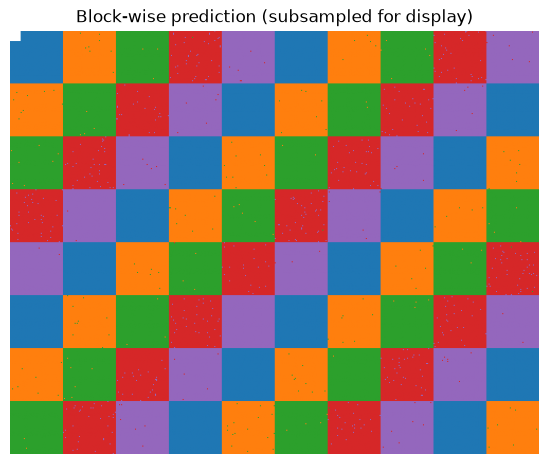

In [6]:
H, W = 2000, 2500                                                             # 5 million pixels
import tempfile
scratch = Path(tempfile.gettempdir())                                       # large rasters go to the temp folder, not the project
image = np.lib.format.open_memmap(scratch / "scene.npy", mode="w+", dtype=np.float32, shape=(6, H, W))
cls_map_true = (np.add.outer(np.arange(H) // 250, np.arange(W) // 250) % 5).astype(np.int8)
for r0 in range(0, H, 500):                                                   # write a synthetic scene in blocks
    blk = cls_map_true[r0:r0 + 500]; image[:, r0:r0 + 500] = (means[blk] + rng.normal(0, 0.015, blk.shape + (6,))).transpose(2, 0, 1)
image.flush(); image[:, :50, :50] = np.nan                                    # nodata corner (e.g. cloud mask)

def predict_raster(src_path, dst_path, block=512):
    img = np.load(src_path, mmap_mode="r"); C, H_, W_ = img.shape
    pred = np.lib.format.open_memmap(dst_path, mode="w+", dtype=np.uint8, shape=(H_, W_))
    for r0 in range(0, H_, block):
        for c0 in range(0, W_, block):
            win = np.asarray(img[:, r0:r0 + block, c0:c0 + block]); h, w = win.shape[1:]
            pix = win.reshape(C, -1).T; ok = ~np.isnan(pix).any(1); lab = np.full(len(pix), 255, np.uint8)  # 255 = nodata
            if ok.any(): lab[ok] = sess.run(outs, {inp: add_ndvi(pix[ok])})[0]
            pred[r0:r0 + h, c0:c0 + w] = lab.reshape(h, w)
    pred.flush(); return pred

t0 = time.perf_counter(); pred_map = predict_raster(scratch / "scene.npy", scratch / "prediction.npy")
print(f"predicted {H * W / 1e6:.1f} M pixels in {time.perf_counter() - t0:.1f}s (block-wise, ONNX Runtime) | accuracy vs truth {np.mean(pred_map[50:, 50:] == cls_map_true[50:, 50:]):.4f}")
plt.figure(figsize=(7, 5.5)); plt.imshow(np.ma.masked_equal(pred_map[::5, ::5], 255), cmap="tab10", vmin=0, vmax=9); plt.title("Block-wise prediction (subsampled for display)"); plt.axis("off"); plt.show()

## **4. A Prediction API With FastAPI**
A small web service: clients send band values as JSON, receive class + probabilities. **Pydantic** validates inputs (types, ranges, lengths) before they reach the model.

In [7]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, field_validator

class PixelBatch(BaseModel):
    pixels: list[list[float]] = Field(..., description="list of [B2, B3, B4, B8, B11, B12] surface reflectances")
    @field_validator("pixels")
    @classmethod
    def check(cls, v):
        if not v or len(v) > 10000: raise ValueError("send between 1 and 10000 pixels")
        for p in v:
            if len(p) != 6: raise ValueError("each pixel needs 6 bands: B2, B3, B4, B8, B11, B12")
            if any((b < 0) or (b > 1.5) for b in p): raise ValueError("reflectance must be in [0, 1.5]")
        return v

api = FastAPI(title="Land-cover prediction API", version=metadata["version"])
API_SESSION = ort.InferenceSession(str(out / "landcover_rf.onnx"), providers=["CPUExecutionProvider"])

@api.get("/health")
def health():
    return {"status": "ok", "model": metadata["model_name"], "version": metadata["version"]}

@api.post("/predict")
def predict(batch: PixelBatch):
    try:
        labels, probs = API_SESSION.run(outs, {inp: add_ndvi(np.array(batch.pixels))})
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"inference failed: {e}")
    return {"model_version": metadata["version"], "predictions": [{"class": CLASSES[int(l)], "probabilities": dict(zip(CLASSES, np.round(p, 4).tolist()))} for l, p in zip(labels, probs)]}

### Testing the API (no server needed)
`TestClient` calls the app in-process. In production we would run `uvicorn app:api --host 0.0.0.0 --port 8000`.

In [8]:
import warnings; warnings.filterwarnings("ignore", message=".*httpx.*")
from fastapi.testclient import TestClient
client = TestClient(api)
print(client.get("/health").json())
r = client.post("/predict", json={"pixels": [[0.03, 0.05, 0.03, 0.36, 0.16, 0.08], [0.06, 0.05, 0.03, 0.02, 0.01, 0.01]]})
print(r.status_code, json.dumps(r.json(), indent=1)[:500])
bad = client.post("/predict", json={"pixels": [[0.1, 0.2, 0.3]]})
print("invalid input ->", bad.status_code, bad.json()["detail"][0]["msg"])

{'status': 'ok', 'model': 'landcover_rf', 'version': '1.0.0'}
200 {
 "model_version": "1.0.0",
 "predictions": [
  {
   "class": "vegetation",
   "probabilities": {
    "water": 0.0,
    "vegetation": 1.0,
    "cropland": 0.0,
    "built-up": 0.0,
    "bare": 0.0
   }
  },
  {
   "class": "water",
   "probabilities": {
    "water": 1.0,
    "vegetation": 0.0,
    "cropland": 0.0,
    "built-up": 0.0,
    "bare": 0.0
   }
  }
 ]
}
invalid input -> 422 Value error, each pixel needs 6 bands: B2, B3, B4, B8, B11, B12


### Automated tests (pytest style)
Tests protect the deployed model from silent breakage when code or dependencies change.

In [9]:
def test_known_pixels():
    r = client.post("/predict", json={"pixels": [list(means[k]) for k in range(5)]})
    assert r.status_code == 200
    assert [p["class"] for p in r.json()["predictions"]] == CLASSES          # class prototypes must map to themselves
def test_probabilities_sum_to_one():
    probs = client.post("/predict", json={"pixels": [list(means[1])]}).json()["predictions"][0]["probabilities"]
    assert abs(sum(probs.values()) - 1) < 1e-3
def test_rejects_wrong_band_count():
    assert client.post("/predict", json={"pixels": [[0.1] * 5]}).status_code == 422
for t in [test_known_pixels, test_probabilities_sum_to_one, test_rejects_wrong_band_count]:
    t(); print("PASSED", t.__name__)

PASSED test_known_pixels
PASSED test_probabilities_sum_to_one
PASSED test_rejects_wrong_band_count


## **5. Containers**
A **Docker** image bundles code, model file, Python and libraries, so the service runs identically on a laptop, a university server or the cloud.
```dockerfile
FROM python:3.12-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt     # fastapi, uvicorn, onnxruntime, numpy, pydantic
COPY app.py landcover_rf.onnx landcover_rf.json ./
EXPOSE 8000
CMD ["uvicorn", "app:api", "--host", "0.0.0.0", "--port", "8000"]
```
`docker build -t landcover-api:1.0.0 .` then `docker run -p 8000:8000 landcover-api:1.0.0`. Deploy to a VM, Kubernetes, or serverless containers (Cloud Run, AWS App Runner). For large-area mapping, batch jobs on Google Earth Engine, Microsoft Planetary Computer or an HPC cluster are often better than a web API.

# **Part 2: Going Deeper - Size, Latency and Versioning**

- **Model size**: a 500-tree forest can be hundreds of MB; limit depth, reduce trees, or distil into a smaller model (train a small model on the big model's predictions).
- **Quantisation** of neural networks (float32 -> int8) shrinks size ~4x and speeds up CPU inference, usually with a small accuracy loss.
- **Versioning**: semantic versions (1.0.0 -> 1.1.0 for retraining, 2.0.0 for changed inputs/outputs); keep old versions available; log the model version with every prediction; roll back if monitoring (Day 83) shows problems.

In [10]:
import torch, torch.nn as nn
net = nn.Sequential(nn.Linear(7, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 5))
opt = torch.optim.Adam(net.parameters(), 1e-3); Xt_, yt_ = torch.tensor(StandardScaler().fit(X_tr).transform(X_tr), dtype=torch.float32), torch.tensor(y_tr)
for _ in range(200): opt.zero_grad(); nn.functional.cross_entropy(net(Xt_), yt_).backward(); opt.step()
warnings.filterwarnings("ignore", message=".*quantiz.*")   # torch.ao.quantization is being migrated to torchao; the API still works
q_net = torch.ao.quantization.quantize_dynamic(net, {nn.Linear}, dtype=torch.qint8)
torch.save(net.state_dict(), out / "fp32.pt"); torch.save(q_net.state_dict(), out / "int8.pt")
Xte_ = torch.tensor(StandardScaler().fit(X_tr).transform(X_te), dtype=torch.float32)
with torch.no_grad(): a32, a8 = (net(Xte_).argmax(1).numpy() == y_te).mean(), (q_net(Xte_).argmax(1).numpy() == y_te).mean()
print(f"float32: {os.path.getsize(out / 'fp32.pt') / 1e3:.0f} kB, accuracy {a32:.4f} | int8 dynamic quantisation: {os.path.getsize(out / 'int8.pt') / 1e3:.0f} kB, accuracy {a8:.4f}")

float32: 279 kB, accuracy 0.9760 | int8 dynamic quantisation: 75 kB, accuracy 0.9740


## **Practice Problems**
1. Add an endpoint `/predict_ndvi_only` that accepts only red and NIR and returns NDVI and a vegetation flag (> 0.4).
2. Write a test that sends 10,001 pixels and checks the API returns HTTP 422.
3. Compare joblib file size for `RandomForestClassifier(500)` with `max_depth=None` vs `max_depth=12`. What is the accuracy cost?
4. *(Advanced)* Export the PyTorch MLP to ONNX with `torch.onnx.export` and verify ONNX Runtime gives the same predictions.

In [11]:
# Solution 2
print("10,001 pixels ->", client.post("/predict", json={"pixels": [[0.1] * 6] * 10001}).status_code)
# Solution 3
for depth in [None, 12]:
    m_ = RandomForestClassifier(500, max_depth=depth, random_state=0, n_jobs=-1).fit(X_tr, y_tr); joblib.dump(m_, out / "tmp.joblib", compress=3)
    print(f"max_depth={depth}: {os.path.getsize(out / 'tmp.joblib') / 1e6:.1f} MB, accuracy {m_.score(X_te, y_te):.4f}")
# Solution 4
torch.onnx.export(net, Xte_[:1], str(out / "mlp.onnx"), input_names=["x"], output_names=["logits"], dynamic_axes={"x": {0: "n"}}, dynamo=False)
s2 = ort.InferenceSession(str(out / "mlp.onnx"), providers=["CPUExecutionProvider"])
with torch.no_grad(): print("PyTorch == ONNX:", np.array_equal(s2.run(None, {"x": Xte_.numpy()})[0].argmax(1), net(Xte_).argmax(1).numpy()))

10,001 pixels -> 422


max_depth=None: 1.9 MB, accuracy 0.9680


max_depth=12: 2.0 MB, accuracy 0.9670
PyTorch == ONNX: True


## **Key References**
- Sculley, D. et al. (2015). Hidden technical debt in machine learning systems. *NeurIPS 28*.
- Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). Challenges in deploying machine learning: A survey of case studies. *ACM Computing Surveys*, 55(6), 114.
- Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). The ML test score: A rubric for ML production readiness and technical debt reduction. *IEEE Big Data 2017*.
- ONNX community (2024). Open Neural Network Exchange. onnx.ai.
- Jacob, B. et al. (2018). Quantization and training of neural networks for efficient integer-arithmetic-only inference. *CVPR 2018*.